In [63]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load Data & Splitting

In [82]:
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR    = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

In [84]:
cs_training = pd.read_csv(DATA_DIR / "cs-training.csv", index_col=0)

In [4]:
# y is a 1-D Series holding the 0/1 default labels
y = cs_training["SeriousDlqin2yrs"]

In [5]:
X = cs_training.drop(columns=["SeriousDlqin2yrs"])

In [6]:
# After the split, X_train and y_train share the same index, so binning stays aligned

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.3,
    random_state=42,
    stratify = y)

In [7]:
numeric_columns = ['RevolvingUtilizationOfUnsecuredLines','MonthlyIncome','DebtRatio_log']
count_columns = ['NumberOfTime30-59DaysPastDueNotWorse','NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate','NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse']
binary_columns = ['IncomeMissing','DependentMissing','HasDependents','InvalidDebtRatio','HighDebt',
                'NumberOfTime30-59DaysPastDueNotWorse_missing','NumberOfTimes90DaysLate_missing',
                   'NumberOfTime60-89DaysPastDueNotWorse_missing']
    

# Functions

In [8]:
def learn_params(X_train, y_train) -> dict:
    params = {}
    params['bin_edges'] = {}

    params['bin_edges']['age'] = [18,25,35,45,55,65,75,120]
    
    # ---- 1.Age ----
    valid_age = X_train.loc[X_train['age'] > 0, 'age']
    params['age_median'] = valid_age.median()
    
    # ---- 2.MonthlyIncome ----
    params['income_upper'] = X_train['MonthlyIncome'].quantile(0.99)
    
    # ---- 3.NumberOfDependents ----
    params['dependents_upper'] = 6
    
    # ---- 4. DebtRatio ----
    # For rows with income present, cap DebtRatio at 5 (above 5 already counts as severe over-indebtedness)
    params['debt_ratio_upper'] = 5
    
    # ---- 5. RevolvingUtilizationOfUnsecuredLines ----
    # Treat 1 as a sensible business boundary and clip this group to a max of 1
    params['revolving_upper'] = 1
    
    # ---- 6. The three past due variables ----
    past_due_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
        "NumberOfTime60-89DaysPastDueNotWorse",
    ]
    params["past_due_medians"] = {}
    for col in past_due_cols:
        valid = X_train.loc[X_train[col] < 90, col]
        params['past_due_medians'][col] = valid.median()
        
    # ---- 7. Compute the median by age group ----
    df = X_train.copy()
    df['age_bins'] = pd.cut(df['age'], bins = params['bin_edges']['age'])
    # Convert to a dict so it can be used for mapping
    params['income_median_by_age'] = df.groupby('age_bins')['MonthlyIncome'].median().to_dict()
    params['dependents_median_by_age'] = df.groupby('age_bins')['NumberOfDependents'].median().to_dict()
    
    # ---- 8. After initial preprocessing, compute bin edges, WoE and IV ----
    df = clean_data(df, params)
    
    # ---- bin_edges ----   
    for col in numeric_columns:
        _, bins = pd.qcut(df[col],q=5,retbins=True,duplicates='drop')
        params['bin_edges'][col] = bins
    for col in past_due_cols:
        params['bin_edges'][col] = {}
        params['bin_edges'][col]['bins'] = [-1, 0, 1, np.inf]
        params['bin_edges'][col]['labels'] = ["0", "1", "2+"]
        
    params['bin_edges']['NumberOfOpenCreditLinesAndLoans'] = {}
    params['bin_edges']['NumberOfOpenCreditLinesAndLoans']['bins'] = [-1, 2, 5, 10, 20, np.inf]
    params['bin_edges']['NumberOfOpenCreditLinesAndLoans']['labels'] = ["0-2", "3-5","6-10","11-20","21+"]
    
    params['bin_edges']['NumberRealEstateLoansOrLines'] = {}
    params['bin_edges']['NumberRealEstateLoansOrLines']['bins'] = [-1, 2, 5, 10, np.inf]
    params['bin_edges']['NumberRealEstateLoansOrLines']['labels'] = ["0-2", "3-5","6-10","10+"]
    
    # ---- compute woe and iv ---
    params["woe_tables"] = {}
    params["iv_values"] = {}
    
    for col in [*numeric_columns, 'age']:
        edges = params['bin_edges'][col]
        woe_table, iv = compute_woe_iv(df[col], y_train, edges)
        params["woe_tables"][col] = woe_table
        params["iv_values"][col] = iv
    
    for col in count_columns:
        edges = params['bin_edges'][col]['bins']
        labels = params['bin_edges'][col]['labels']
        woe_table, iv = compute_woe_iv_count(df[col],y_train,edges,labels)
        params["woe_tables"][col] = woe_table
        params["iv_values"][col] = iv
        
    for col in binary_columns:
        woe_table, iv = compute_woe_iv_binary(df[col],y_train)
        params['woe_tables'][col] = woe_table
        params['iv_values'][col] = iv
        
    
    
    return params

In [9]:
def clean_data(df, params):
    df = df.copy()
    
    # ----1. Age ----
    # Fill age == 0 with the median age
    df.loc[df["age"] == 0, "age"] = params["age_median"]
    df['age_bins'] = pd.cut(df['age'], bins = params['bin_edges']['age'])
    
    # ----2. MonthlyIncome ----
    # Turn invalid incomes of 0/1 into missing values
    # Add a missing-value flag
    # Fill income with the per-age-group median
    # Clip the upper bound of monthly income
    df.loc[df["MonthlyIncome"] <= 1, "MonthlyIncome"] = np.nan
    df['IncomeMissing'] = df['MonthlyIncome'].isna().astype(int)
    
    # Build a Series of fill values: index is the unchanged row index (105,000 rows), values are each age bin's median income
    # Must cast the mapped result to float, otherwise fillna hits a category-vs-float mismatch and stalls
    income_fill_values = df['age_bins'].map(params['income_median_by_age']).astype(float)
    df['MonthlyIncome'] = df['MonthlyIncome'].fillna(income_fill_values)
    
    df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper = params['income_upper'])
    
    # ----3. NumberOfDependents ----
    # Add missing flag, fill with per-age-group median, clip the max
    # Create the HasDependents binary variable
    df['DependentMissing'] = df["NumberOfDependents"].isna().astype(int)
    
    dependents_fill_values = df['age_bins'].map(params['dependents_median_by_age']).astype(float)
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(dependents_fill_values)
    
    df['NumberOfDependents'] = df['NumberOfDependents'].clip(upper = params['dependents_upper'])
    
    df['HasDependents'] = (df['NumberOfDependents'] > 0).astype(int)
    
    # ----4. DebtRatio ----
    # Keep the invalid-debt flag and set the invalid DebtRatio to NaN, letting the model learn from it
    # clip(upper=5)
    # Log-transform DebtRatio to make the values more stable
    # HighDebt flag
    df['InvalidDebtRatio'] = df['IncomeMissing']
    df.loc[df['IncomeMissing']==1, 'DebtRatio'] = np.nan
    df.loc[df["IncomeMissing"]== 0, "DebtRatio"] = df.loc[df["IncomeMissing"] == 0, "DebtRatio"].clip(upper=5)
    df['DebtRatio_log'] = np.log1p(df['DebtRatio'])
    df['HighDebt'] = (df['DebtRatio']>1).astype(int)
    
    # ---- 5. Revolving Utillizaiton of Unsecured Lines ----
    # Clip the max to 1
    df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)
    
    
    # ---- 6.Past-due variables: irregular 96/98 values ----
    # Treat 96 and 98 as missing counts: all three count fields showing 96/98 with identical frequencies is clearly implausible
    # Keep the missing flag, then fill
    late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"]
    
    for col in late_cols:
        df.loc[df[col].isin([96,98]),col] = np.nan
        
    for col in late_cols:    
        df[col+'_missing'] = df[col].isna().astype(int)

    for col in late_cols:
        df[col] = df[col].fillna(params['past_due_medians'][col])
    
    return df

In [10]:
def compute_woe_iv(feature:pd.Series, target:pd.Series, bin_edges:np.ndarray) -> tuple:
    '''
    feature: the column to be binned
    target: the y_train labels
    bin_edges: the pre-fixed bin boundaries
    '''
    bins = pd.cut(feature, bins=bin_edges, include_lowest = True)
    if bins.isna().any():
        bins = bins.astype(object).fillna('Missing')
    df = pd.DataFrame({'bin': bins, 'y':target.values})
    
    # Aggregate good/bad counts per bin
    agg = df.groupby('bin')['y'].agg(['sum','count'])
    agg.columns = ['n_bad','n_total']
    agg['n_good'] = agg['n_total']-agg['n_bad']
    
    total_bad = agg['n_bad'].sum()
    total_good = agg['n_good'].sum()
    
    agg['woe'] = np.log(agg['n_good']/total_good)-np.log(agg['n_bad']/total_bad)
    agg['iv_contribution'] = ((agg['n_good']/total_good)-(agg['n_bad']/total_bad))*agg['woe']
    
    iv = agg["iv_contribution"].sum()
    
    return agg[["n_good", "n_bad", "woe"]].reset_index(), iv

In [11]:
def compute_woe_iv_count(feature: pd.Series, target: pd.Series, bin_edges: np.ndarray, labels) -> tuple:
    '''
    feature: the column to be binned
    target: the y_train labels
    bin_edges: the pre-fixed bin boundaries
    '''
    bins = pd.cut(feature, bins = bin_edges, labels = labels, include_lowest=True)
    df = pd.DataFrame({'bin':bins, 'y':target.values})
    
    agg = df.groupby('bin')['y'].agg(['sum','count'])
    agg.columns = ['n_bad','n_count']
    agg['n_good'] = agg['n_count']-agg['n_bad']
    
    total_good = agg['n_good'].sum()
    total_bad = agg['n_bad'].sum()
    
    agg['woe'] = np.log(agg['n_good']/total_good)-np.log(agg['n_bad']/total_bad)
    agg['iv_contribution'] = ((agg['n_good']/total_good)-(agg['n_bad']/total_bad))*(agg['woe'])
    
    iv = agg['iv_contribution'].sum()
    
    return agg[['n_good','n_bad','woe']].reset_index(), iv

In [12]:
def compute_woe_iv_binary(feature: pd.Series, target: pd.Series) -> tuple:
    '''
    binary features can be grouped by their own values directly
    '''
    df = pd.DataFrame({'bin':feature.values, 'y':target.values})
    agg = df.groupby('bin')['y'].agg(['sum','count'])
    
    agg.columns = ['n_bad','n_count']
    agg['n_good'] = agg['n_count']-agg['n_bad']
    
    total_good = agg['n_good'].sum()
    total_bad = agg['n_bad'].sum()
    
    agg['woe'] = np.log(agg['n_good']/total_good)-np.log(agg['n_bad']/total_bad)
    agg['iv_contribution'] = ((agg['n_good']/total_good)-(agg['n_bad']/total_bad))*agg['woe']
    
    iv = agg['iv_contribution'].sum()
    
    return agg[['n_bad','n_good','woe']].reset_index(), iv

In [23]:
def apply_binning(df:pd.DataFrame, params:dict) -> pd.DataFrame:
    df = df.copy()
    
    for col in df.columns:
        if col in [*numeric_columns, 'age']:
            binned = pd.cut(df[col], bins = params['bin_edges'][col], include_lowest = True)
            if "Missing" in params["woe_tables"][col]['bin'].astype(str).tolist():
                binned = binned.astype(object).fillna("Missing")
            df[f"{col}_bins"] = binned
        if col in count_columns:
            df[f"{col}_bins"] = pd.cut(df[col], 
                                       bins = params['bin_edges'][col]['bins'], 
                                       labels = params['bin_edges'][col]['labels'])
            
    return df

In [28]:
def apply_woe_values(df:pd.DataFrame, params:dict) -> pd.DataFrame:
    df = df.copy()
    
    for col in params['woe_tables']:
        if col in binary_columns:
            new_col = col + '_woe'
            df[new_col] = df[col].map(params['woe_tables'][col].set_index('bin')['woe'].to_dict())
        else:
            new_col = col + '_woe'
            df[new_col] = df[f"{col}_bins"].map(params['woe_tables'][col].set_index('bin')['woe'].to_dict())
            
    return df

In [15]:
def calculate_ks(y_true: pd.Series, y_pred_proba: np.ndarray) -> float:
    """
    Kolmogorov-Smirnov statistic for binary classifiers.

    KS measures the maximum vertical distance between the cumulative
    distribution functions of predictions for the good and bad classes.

    Industry benchmarks for credit scoring:
        KS < 0.20: worthless
        KS > 0.70: too good to be true
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred_proba)

    # Sort by predicted probability
    order = np.argsort(y_pred) #Returns the indices that would sort an array.
    y_sorted = y_true[order]

    # Cumulative distributions
    # Sort by predicted y_pred, then compute cumulative percentages and KS from the sorted y_true
    cum_bad = np.cumsum(y_sorted) / max(y_sorted.sum(), 1)
    cum_good = np.cumsum(1 - y_sorted) / max((1 - y_sorted).sum(), 1)

    return np.max(np.abs(cum_good - cum_bad))


In [16]:
def evaluate_model(y_true: pd.Series, y_pred_proba: np.ndarray) -> dict:
    """
    Industry-standard credit risk evaluation report.

    Returns a dict with:
        AUC          : standard
        Gini         : 2*AUC - 1, business-friendly
        KS           : maximum separation of good/bad CDFs
    """
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    ks = calculate_ks(y_true, y_pred_proba)
    
    return {
        "AUC": auc,
        "Gini": gini,
        "KS": ks,
    }

# Main Pipeline

## training set

In [17]:
params= learn_params(X_train, y_train)

In [18]:
X_train_cleaned = clean_data(X_train, params)

In [24]:
X_train_binned = apply_binning(X_train_cleaned, params)

In [29]:
X_train_woe = apply_woe_values(X_train_binned, params)

In [33]:
X_train_woe = X_train_woe.filter(like='woe').astype(float)

In [34]:
model_features = [
    'age_woe',
    'RevolvingUtilizationOfUnsecuredLines_woe',
    'MonthlyIncome_woe',
    'DebtRatio_log_woe',
    'NumberOfTime30-59DaysPastDueNotWorse_woe',
    'NumberOfTimes90DaysLate_woe',
    'NumberOfTime60-89DaysPastDueNotWorse_woe',
    'NumberOfOpenCreditLinesAndLoans_woe',
    'HasDependents_woe',
    'HighDebt_woe',
    'NumberOfTimes90DaysLate_missing_woe'
]

In [35]:
X_train_woe = X_train_woe[model_features]

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_woe, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
coef_table = pd.DataFrame({
    'Feature': X_train_woe.columns,
    'Coef': model.coef_[0]
})

coef_table.sort_values(
    by='Coef'
)

,Feature,Coef
10,NumberOfTimes90DaysLate_missing_woe,-0.853858
3,DebtRatio_log_woe,-0.651998
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.603310
5,NumberOfTimes90DaysLate_woe,-0.563263
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.536461
0,age_woe,-0.445490
6,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.429045
9,HighDebt_woe,-0.370577
7,NumberOfOpenCreditLinesAndLoans_woe,-0.265231
8,HasDependents_woe,-0.125717


In [38]:
y_pred_prob = model.predict_proba(
    X_train_woe
)[:,1]

In [39]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    y_train,
    y_pred_prob
)

0.8553951485345896

In [40]:
evaluate_model(y_train, y_pred_prob)

{'AUC': 0.8553951485345896,
 'Gini': 0.7107902970691793,
 'KS': 0.5569289836294542}

In [41]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train_woe, y_train, cv=5, scoring='roc_auc')
print(f"5-fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-fold CV AUC: 0.8552 ± 0.0065


## Test Set

In [42]:
X_test_cleaned = clean_data(X_test, params)

In [43]:
X_test_binned = apply_binning(X_test_cleaned, params)

In [44]:
X_test_woe = apply_woe_values(X_test_binned, params)

In [45]:
X_test_woe = X_test_woe.filter(like='woe').astype(float)

In [47]:
X_test_woe.isna().sum()

RevolvingUtilizationOfUnsecuredLines_woe            0
MonthlyIncome_woe                                   0
DebtRatio_log_woe                                   0
age_woe                                             0
NumberOfTime30-59DaysPastDueNotWorse_woe            0
NumberOfOpenCreditLinesAndLoans_woe                 0
NumberOfTimes90DaysLate_woe                         0
NumberRealEstateLoansOrLines_woe                    0
NumberOfTime60-89DaysPastDueNotWorse_woe            0
IncomeMissing_woe                                   0
DependentMissing_woe                                0
HasDependents_woe                                   0
InvalidDebtRatio_woe                                0
HighDebt_woe                                        0
NumberOfTime30-59DaysPastDueNotWorse_missing_woe    0
NumberOfTimes90DaysLate_missing_woe                 0
NumberOfTime60-89DaysPastDueNotWorse_missing_woe    0
dtype: int64

In [48]:
X_test_model = X_test_woe[model_features]

In [49]:
y_test_prob = model.predict_proba(
    X_test_model
)[:,1]

In [50]:
roc_auc_score(
    y_test,
    y_test_prob
)

0.8558762213889272

In [51]:
evaluate_model(y_test,y_test_prob)

{'AUC': 0.8558762213889272,
 'Gini': 0.7117524427778543,
 'KS': 0.5562813636234663}

# CS-test

In [90]:
cs_test = pd.read_csv(DATA_DIR / "cs-test.csv", index_col=0)

In [91]:
cs_test = cs_test.drop(columns = ['SeriousDlqin2yrs'])

In [92]:
cs_test_cleaned = clean_data(cs_test, params)

In [93]:
cs_test_binned = apply_binning(cs_test_cleaned, params)

In [94]:
cs_test_woe = apply_woe_values(cs_test_binned, params)

In [95]:
cs_test_woe = cs_test_woe.filter(like='woe').astype(float)

In [96]:
cs_test_woe.isna().sum()

RevolvingUtilizationOfUnsecuredLines_woe            0
MonthlyIncome_woe                                   0
DebtRatio_log_woe                                   0
age_woe                                             0
NumberOfTime30-59DaysPastDueNotWorse_woe            0
NumberOfOpenCreditLinesAndLoans_woe                 0
NumberOfTimes90DaysLate_woe                         0
NumberRealEstateLoansOrLines_woe                    0
NumberOfTime60-89DaysPastDueNotWorse_woe            0
IncomeMissing_woe                                   0
DependentMissing_woe                                0
HasDependents_woe                                   0
InvalidDebtRatio_woe                                0
HighDebt_woe                                        0
NumberOfTime30-59DaysPastDueNotWorse_missing_woe    0
NumberOfTimes90DaysLate_missing_woe                 0
NumberOfTime60-89DaysPastDueNotWorse_missing_woe    0
dtype: int64

In [98]:
X_submit = cs_test_woe[model_features]

In [99]:
submission_prob = model.predict_proba(
    X_submit
)[:,1]

In [100]:
submission = pd.DataFrame({
    'Id': range(1, len(submission_prob)+1),
    'Probability': submission_prob
})

submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)

# ScoreCard

In [52]:
# Convert a (WoE-encoded) logistic regression into a points-based scorecard
# in the 300-850 style. 
#
# Formula:
#     Score = A - B * ln(odds_of_default)
# where:
#     B = pdo / ln(2)                    # PDO = "points to double odds"
#     A = base_score + B * ln(base_odds)
#
# Each variable contributes points equal to:
#     points_i = -B * (beta_i * WoE_i + intercept / n_features)
#
# A customer's final score = sum of points from all their variables.
# =============================================================================

def build_scorecard(
    model,
    feature_names: list,
    params: dict,
    base_score: int = 600,
    base_odds: float = 50,
    pdo: int = 20,
) -> pd.DataFrame:
    """
    Build a points-based credit scorecard from a trained logistic regression.

    Parameters
    ----------
    model : trained sklearn LogisticRegression (on WoE-encoded data)
    feature_names : list of WoE feature names (same order as model.coef_)
    params : dict, output of learn_params()
    base_score : score corresponding to base_odds
    base_odds : odds at the base score
    pdo : points to double the odds (industry standard: 20)

    Returns
    -------
    scorecard : pd.DataFrame with columns [feature, bin, woe, beta, points]
    """
    B = pdo / np.log(2)
    A = base_score + B * np.log(base_odds)

    intercept = model.intercept_[0]
    coefs = model.coef_[0]
    n_features = len(feature_names)

    rows = []
    for col, beta in zip(feature_names, coefs):
        # Strip the "_woe" suffix to find the original column name
        original_col = col.replace("_woe", "")
        if original_col not in params["woe_tables"]:
            continue
        woe_table = params["woe_tables"][original_col]

        for _, r in woe_table.iterrows():  # iterate row-wise; first value is the index (discarded), second is the row as a Series
            points = -B * (beta * r["woe"] + intercept / n_features)
            rows.append({
                "feature": original_col,
                "bin": str(r["bin"]),
                "n_good": r["n_good"],
                "n_bad": r["n_bad"],
                "woe": r["woe"],
                "beta": beta,
                "points": round(points, 2),
            })

    scorecard = pd.DataFrame(rows)  # a list of dicts converts directly into a DataFrame
    scorecard.attrs["base_score"] = base_score
    scorecard.attrs["A"] = A
    scorecard.attrs["B"] = B
    return scorecard

In [53]:
def score_customer(woe_row: pd.Series, model, base_score: int = 600,
                   base_odds: float = 50, pdo: int = 20) -> float:
    """
    Compute the credit score for one customer (one row of WoE-encoded features).

    This is the production-equivalent of model.predict_proba(), but on the
    score scale (e.g. 300-850) rather than probability scale.
    """
    B = pdo / np.log(2)
    A = base_score + B * np.log(base_odds)

    linear_score = model.intercept_[0] + np.dot(woe_row.values, model.coef_[0])
    score = A - B * linear_score
    return score


In [54]:
scorecard = build_scorecard(model, feature_names = X_train_woe.columns.to_list(),params = params)

In [55]:
scorecard

,feature,bin,n_good,n_bad,woe,beta,points
0,age,"(17.999, 25.0]",1935.0,234.0,-0.523764,-0.445490,0.14
1,age,"(25.0, 35.0]",11423.0,1398.0,-0.535719,-0.445490,-0.02
2,age,"(35.0, 45.0]",19102.0,1845.0,-0.298992,-0.445490,3.03
3,age,"(45.0, 55.0]",23724.0,1934.0,-0.129409,-0.445490,5.21
4,age,"(55.0, 65.0]",22399.0,1114.0,0.364754,-0.445490,11.56
5,age,"(65.0, 75.0]",12484.0,343.0,0.958167,-0.445490,19.18
6,age,"(75.0, 120.0]",6915.0,150.0,1.194507,-0.445490,22.22
7,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.0189]",20594.0,406.0,1.290096,-0.603310,29.33
8,RevolvingUtilizationOfUnsecuredLines,"(0.0189, 0.0827]",20637.0,363.0,1.404133,-0.603310,31.31
9,RevolvingUtilizationOfUnsecuredLines,"(0.0827, 0.272]",20416.0,584.0,0.917868,-0.603310,22.85


# Band Monotonic test

In [86]:
def rank_ordering_table(scores, y_true, n_bins=10):
    """
    Decile rank-ordering check for a credit scorecard.

    """
    d = pd.DataFrame({"score": np.asarray(scores), "y": np.asarray(y_true)})
    d["band"] = pd.qcut(d["score"], n_bins)
    agg = d.groupby("band", observed=False)["y"].agg(count="count", n_bad="sum")
    agg["bad_rate"] = agg["n_bad"] / agg["count"]
    return agg

In [87]:
def plot_rank_ordering(agg, ax=None):
    """Plot bad rate by score band (expects the output of rank_ordering_table)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(len(agg)), agg["bad_rate"], marker="o")
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels([str(b) for b in agg.index], rotation=45, ha="right")
    ax.set_xlabel("Score Band")
    ax.set_ylabel("Bad Rate")
    ax.set_title("Bad Rate by Score Band")
    return ax

In [56]:
scores = X_test_model.apply(
    lambda row: score_customer(row, model),
    axis=1
)

In [88]:
agg = rank_ordering_table(scores, y_test, n_bins=10)
print("monotonic decreasing?", agg["bad_rate"].is_monotonic_decreasing)   # True = rank ordering holds
agg

monotonic decreasing? True


,count,n_bad,bad_rate
band,,,
"(638.063, 765.161]",4500,1617,0.359333
"(765.161, 783.839]",4500,525,0.116667
"(783.839, 798.625]",4500,294,0.065333
"(798.625, 807.774]",4500,178,0.039556
"(807.774, 818.097]",4500,146,0.032444
"(818.097, 825.221]",4502,90,0.019991
"(825.221, 830.81]",4500,65,0.014444
"(830.81, 836.055]",4588,39,0.008500
"(836.055, 842.773]",4417,32,0.007245


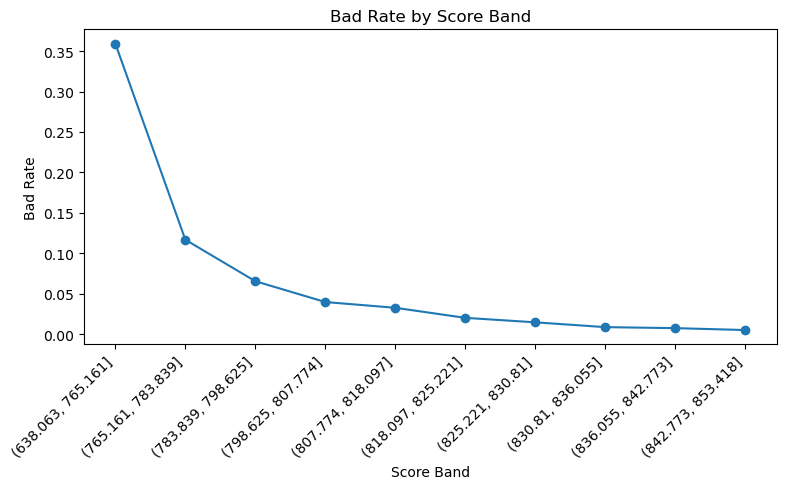

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_rank_ordering(agg, ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "bad_rate_by_score_band.png", dpi=120)
plt.show()